# Paper III Methodology Notebook

This notebook presents the main numerical methodology and result artifacts from Paper III using the public synthetic DS2 replacement dataset.

The original paper combines NaMo predictions with XGBoost predictions through an adaptive density-based coefficient. Because the proprietary NaMo output is not available here, this notebook generates deterministic synthetic replacement NaMo estimates. The method, figure logic, and analysis sequence are otherwise the Paper III methodology. 

Paper III:
*Øien, Christian Dalheim; Myhr, Ole Runar; Ringen, Geir. Parallel Hybrid
Modeling of Al–Mg–Si Tensile Properties Using Density-Based Weighting.
Metals 16 (2026), 142.
DOI: https://doi.org/10.3390/met16020142*



## 1. Setup

Import dependencies, define input/output paths, and set the fixed hyperparameters used for the XGBoost model and coefficient model. The coefficient parameters follow the selected Paper III values: `k=8`, `a=1`, `N1=200`, and `N2=2000`.

In [1]:
import os
from pathlib import Path
from datetime import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
import xgboost as xgb

from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error, r2_score

from coeff_field import (
    build_coeff_model,
    coefficient_for_point,
    coefficient_for_point_no_size_scale,
)

mpl.rcParams['figure.dpi'] = 150 # 300 used in paper
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 90)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", 800)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

DATA_DIR = Path("../paper_II/data")
DATA_PATH = DATA_DIR / "DS2_full.xlsx"

OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)

# Excel for storing synthetic replacement NaMo estimates generated by this notebook.
SYNTHETIC_NAMO_PATH = OUTPUT_DIR / "NaMo_synthetic_paper_III.xlsx"
REGENERATE_SYNTHETIC_NAMO = True

RANDOM_SEED_SPLIT = 1234
RANDOM_SEED_SECOND_STAGE = 42
RANDOM_SEED_SYNTHETIC_NAMO = 42

Y_COLS = ["Rp0.2 [MPa]", "Rm [MPa]"]
COEFF_COLS = ["Mg [wt.%]", "Si [wt.%]", "Ageing_holding_temperature", "Scheil norm"]

XGB_PARAMS = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "subsample": 0.8,
    "colsample_bytree": 0.5,
    "alpha": 0.1,
    "lambda": 0.9,
    "gamma": 0.01,
    "learning_rate": 0.08,
    "max_depth": 4,
    "n_estimators": 500,
}

N_STEPS = 20
FIRST_TRAIN_SIZE = 100

# Paper III coefficient-model hyperparameters.
COEFF_PARAMS = {
    "k": 8,
    "sharpness": 1,
    "n1": 200,
    "n2": 2000,
    "sample_size": 10_000,
}

k = COEFF_PARAMS["k"]
sharpness = COEFF_PARAMS["sharpness"]
n1 = COEFF_PARAMS["n1"]
n2 = COEFF_PARAMS["n2"]

## 2. Helper functions

Define utilities for RMSE calculation, train-size construction, normalization, XGBoost fitting, synthetic NaMo generation, feature selection, and hybrid prediction assembly.

In [2]:
def safe_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) == 0:
        return np.nan
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def g_of_n(n, n1, n2):
    if n <= n1:
        return 0.0
    if n >= n2:
        return 1.0
    return float((np.log10(n) - np.log10(n1)) / (np.log10(n2) - np.log10(n1)))

def make_train_sizes(n_train_rows, n_steps=N_STEPS, first_size=FIRST_TRAIN_SIZE):
    """
    Construct the incremental training sizes used in the Paper III
    numerical experiment.
    """
    if n_train_rows < first_size:
        raise ValueError(
            f"n_train_rows={n_train_rows} is smaller than first_size={first_size}."
        )

    return np.linspace(first_size, n_train_rows, n_steps, dtype=int)

def find_iter_index_for_N(N, sizes=None):
    """ Return index in train_sizes closest to N."""
    if sizes is None:
        sizes = train_sizes

    arr = np.asarray(sizes)
    exact = np.where(arr == N)[0]
    if len(exact):
        return int(exact[0])

    return int(np.argmin(np.abs(arr - N)))


def normalize_with_stats(X, mean, std):
    std = std.replace(0, 1.0)
    return (X - mean) / std


def fit_xgb(X_train, y_train):
    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)
    return model


def generate_synthetic_namo_estimates(df, seed=RANDOM_SEED_SYNTHETIC_NAMO):
    """
    Generate deterministic replacement NaMo-like estimates.

    These are not physical NaMo predictions. They are fixed synthetic PBM-like
    estimates used to run the Paper III methodology without proprietary
    NaMo output.

    Design intent:
    - fixed per row, independent of training-set size
    - smoother and less locally adaptive than XGBoost
    - broadly sensitive to Mg, Si, T, I and secondary alloying additions
    - moderate residual spread relative to measured Rp0.2 and Rm
    - same index as DS2 input, so they can be exported and rejoined cleanly
    """
    rng = np.random.default_rng(seed)

    rp_true = df["Rp0.2 [MPa]"].astype(float).to_numpy()
    rm_true = df["Rm [MPa]"].astype(float).to_numpy()

    mg = df["Mg [wt.%]"].astype(float).to_numpy()
    si = df["Si [wt.%]"].astype(float).to_numpy()
    temp = df["Ageing_holding_temperature"].astype(float).to_numpy()
    scheil = df["Scheil norm"].astype(float).to_numpy()

    fe = df["Fe [wt.%]"].astype(float).to_numpy() if "Fe [wt.%]" in df.columns else np.zeros(len(df))
    mn = df["Mn [wt.%]"].astype(float).to_numpy() if "Mn [wt.%]" in df.columns else np.zeros(len(df))
    cu = df["Cu [wt.%]"].astype(float).to_numpy() if "Cu [wt.%]" in df.columns else np.zeros(len(df))
    cr = df["Cr [wt.%]"].astype(float).to_numpy() if "Cr [wt.%]" in df.columns else np.zeros(len(df))

    is_6060 = (mg < 0.6) & (si < 0.6)

    # Smooth systematic residual structure. This creates a PBM-like estimate
    # that is related to the same physical drivers but not equal to the target.
    chem_residual = (
        7.0 * (mg - np.nanmedian(mg))
        - 5.0 * (si - np.nanmedian(si))
        - 8.0 * fe
        + 8.0 * mn
        + 14.0 * cu
        + 10.0 * cr
    )

    age_residual = (
        0.25 * (temp - 185.0)
        - 9.0 * (scheil - np.nanmedian(scheil))
        - 10.0 * np.maximum(temp - 200.0, 0.0) / 25.0
    )

    regime_residual = np.where(
        is_6060,
        -3.0 + 9.0 * (0.6 - mg) + 9.0 * (0.6 - si),
        3.0 * np.tanh((mg + si - 1.1) / 0.30),
    )

    rp_noise = rng.normal(0.0, np.where(is_6060, 18.0, 16.0), len(df))

    rp_residual = chem_residual + age_residual + regime_residual + rp_noise
    rp_residual = np.clip(rp_residual, -65.0, 65.0)

    namo_rp02 = np.clip(rp_true + rp_residual, 50.0, 390.0)

    rm_gap = rm_true - rp_true
    rm_gap_centered = rm_gap - np.nanmedian(rm_gap)

    rm_residual = (
        0.65 * rp_residual
        + 0.25 * rm_gap_centered
        + rng.normal(0.0, 8.0, len(df))
    )
    rm_residual = np.clip(rm_residual, -70.0, 70.0)

    namo_rm = np.clip(rm_true + rm_residual, 80.0, 430.0)
    namo_rm = np.maximum(namo_rm, namo_rp02 + 8.0)

    namo_df = pd.DataFrame(
        {
            "NaMo Rp02": np.round(namo_rp02, 1),
            "NaMo Rm": np.round(namo_rm, 1),
        },
        index=df.index,
    )

    return namo_df


def get_feature_frame(df_in):
    """
    Construct the DDM feature matrix by dropping target, synthetic PBM,
    grouping, and metadata columns, then retaining numeric columns only.
    """
    drop_cols = [
        "data_set_name",
        "Alloy_number / identifier",
        "NaMo Rp02",
        "NaMo Rm",
        "natural_ageing_time [minutes]",
        "artificial_ageing_time [minutes]",
        "ageing_cycle_type [name]",
        "A [%]",
        "Ag [%]",
        "is_6060",
        "alloy_type",
        "idx",
        "overheated [boolean]",
    ]

    X = df_in.drop(columns=drop_cols + Y_COLS, errors="ignore")
    X = X.select_dtypes(include=[np.number]).copy()
    return X


def make_prediction_frame(df_eval, y_pred):
    out = pd.DataFrame(
        {
            "Rp0.2_test": df_eval["Rp0.2 [MPa]"].to_numpy(),
            "Rp0.2_xgb": y_pred[:, 0],
            "Rm_test": df_eval["Rm [MPa]"].to_numpy(),
            "Rm_xgb": y_pred[:, 1],
            "is_6060": df_eval["is_6060"].to_numpy(),
            "alloy_type": df_eval["alloy_type"].to_numpy(),
            "NaMo Rp02": df_eval["NaMo Rp02"].to_numpy(),
            "NaMo Rm": df_eval["NaMo Rm"].to_numpy(),
        },
        index=df_eval.index,
    )
    return out

## 3. Load DS2 and create replacement NaMo estimates

Load the synthetic DS2 replacement dataset, harmonize column names, reconstruct the aging holding temperature if needed, and define the `6060` regime as `Mg < 0.6 wt.%` and `Si < 0.6 wt.%`.

Synthetic NaMo-like estimates are generated or loaded with the same index as DS2, so they can act as fixed PBM predictions throughout the incremental experiment.

In [3]:
df = pd.read_excel(DATA_PATH, index_col=0).copy()

# Column-name harmonization.
df = df.rename(
    columns={
        "Rp0.2 [Mpa]": "Rp0.2 [MPa]",
        "Scheil": "Scheil norm",
    }
)

# Match the original working notebook: exclude NaMo-comparison rows if present.
if "data_set_name" in df.columns:
    df = df.loc[df["data_set_name"] != "NaMo comparison"].copy()

# Reconstruct holding temperature if needed.
if "Ageing_holding_temperature" not in df.columns:
    df["Ageing_holding_temperature"] = df[["T7", "T9"]].max(axis=1)

# Paper III only distinguishes the introduced 6060 regime from the rest.
df["is_6060"] = (df["Mg [wt.%]"] < 0.6) & (df["Si [wt.%]"] < 0.6)
df["alloy_type"] = np.where(df["is_6060"], "6060", "non-6060")

# Generate or reload synthetic replacement NaMo estimates.
if REGENERATE_SYNTHETIC_NAMO or not SYNTHETIC_NAMO_PATH.exists():
    namo_df = generate_synthetic_namo_estimates(df)
    SYNTHETIC_NAMO_PATH.parent.mkdir(exist_ok=True)
    namo_df.to_excel(SYNTHETIC_NAMO_PATH)
    print(f"Generated synthetic replacement NaMo estimates: {SYNTHETIC_NAMO_PATH}")
else:
    namo_df = pd.read_excel(SYNTHETIC_NAMO_PATH, index_col=0)
    print(f"Loaded synthetic replacement NaMo estimates: {SYNTHETIC_NAMO_PATH}")

# Join using the same index.
missing_idx = namo_df.index.difference(df.index)
if len(missing_idx) > 0:
    raise ValueError(f"{len(missing_idx)} NaMo rows are missing from DS2 input.")

df = df.join(namo_df[["NaMo Rp02", "NaMo Rm"]], how="left")

required_cols = Y_COLS + COEFF_COLS + ["NaMo Rp02", "NaMo Rm", "is_6060", "alloy_type"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Dataset shape:", df.shape)
print("6060 share:", round(float(df["is_6060"].mean()), 3))
print("Synthetic NaMo file:", SYNTHETIC_NAMO_PATH)
print("DDM feature columns:", len(get_feature_frame(df)))


display(df[Y_COLS + ["NaMo Rp02", "NaMo Rm"] + COEFF_COLS + ["alloy_type"]].head())

Generated synthetic replacement NaMo estimates: data\NaMo_synthetic_paper_III.xlsx
Dataset shape: (2990, 23)
6060 share: 0.413
Synthetic NaMo file: data\NaMo_synthetic_paper_III.xlsx
DDM feature columns: 2990


,Rp0.2 [MPa],Rm [MPa],NaMo Rp02,NaMo Rm,Mg [wt.%],Si [wt.%],Ageing_holding_temperature,Scheil norm,alloy_type
id,,,,,,,,,
1,141.500,211.400,153.300,225.500,0.435,0.485,180,0.010,6060
2,132.100,187.900,119.700,190.700,0.435,0.485,180,0.012,6060
3,143.700,211.800,164.700,225.900,0.435,0.485,185,0.013,6060
4,136.800,198.100,161.200,232.300,0.435,0.485,185,0.016,6060
5,160.800,212.700,134.400,188.500,0.435,0.485,190,0.019,6060


## 4. Construct the distribution-shift experiment

Shuffle the dataset, split it into training, validation, and test sets, and move the `6060` rows in the training set into the second half of the training sequence.

This recreates the Paper III numerical experiment: XGBoost initially sees little or no `6060` chemistry, while the test set remains fixed.

In [4]:
test_frac = 0.10
val_frac = 0.10

df_shuffled = df.sample(frac=1, random_state=RANDOM_SEED_SPLIT).reset_index(drop=True)

n_test = int(len(df_shuffled) * test_frac)
n_val = int(len(df_shuffled) * val_frac)

df_test = df_shuffled.iloc[:n_test].copy()
df_val = df_shuffled.iloc[n_test:n_test + n_val].copy()
df_train_pool = df_shuffled.iloc[n_test + n_val:].copy()

# Late introduction of the 6060 regime.
df_train_6060 = df_train_pool[df_train_pool["is_6060"]]
df_train_non6060 = df_train_pool[~df_train_pool["is_6060"]]

half_train = len(df_train_pool) // 2

df_train_part1 = df_train_non6060.iloc[:half_train]
df_train_part2 = pd.concat(
    [df_train_6060, df_train_non6060.iloc[half_train:]],
    axis=0,
).sample(frac=1, random_state=RANDOM_SEED_SECOND_STAGE)

df_train_seq = pd.concat(
    [df_train_part1, df_train_part2],
    axis=0,
).reset_index(drop=True)

train_sizes = make_train_sizes(
    n_train_rows=len(df_train_seq),
    n_steps=N_STEPS,
    first_size=FIRST_TRAIN_SIZE,
)

print("Incremental training sizes:")
print(train_sizes)

df_full = pd.concat(
    [df_train_seq, df_val, df_test],
    ignore_index=True,
)

breakpoints = [
    half_train,
    len(df_train_seq),
    len(df_train_seq) + len(df_val),
]

print("Train/validation/test sizes:")
print(len(df_train_seq), len(df_val), len(df_test))
print("Breakpoints:", breakpoints)
print("6060 rows in first half of training:", int(df_train_seq.iloc[:half_train]["is_6060"].sum()))
print("6060 rows in second half of training:", int(df_train_seq.iloc[half_train:]["is_6060"].sum()))

Incremental training sizes:
[ 100  220  341  461  582  703  823  944 1065 1185 1306 1426 1547 1668
 1788 1909 2030 2150 2271 2392]
Train/validation/test sizes:
2392 299 299
Breakpoints: [1196, 2392, 2691]
6060 rows in first half of training: 0
6060 rows in second half of training: 981


## 5. Train XGBoost and recompute the hybrid incrementally

Train XGBoost on increasingly larger prefixes of the reordered training sequence. At each increment, recompute the density-based coefficient model in the reduced `(Mg, Si, T, I)` trust space and blend the XGBoost and synthetic NaMo predictions.

Validation predictions are kept for robustness comparisons, while test predictions are used for the main figures and RMSE summaries.

In [5]:
# Feature matrices.
X_train_pool = get_feature_frame(df_train_seq)
X_val_raw = get_feature_frame(df_val)
X_test_raw = get_feature_frame(df_test)

# Match the original notebook treatment: held-out matrices normalized using
# the full disruptive training-pool statistics.
train_pool_mean = X_train_pool.mean()
train_pool_std = X_train_pool.std().replace(0, 1.0)

X_val = normalize_with_stats(X_val_raw, train_pool_mean, train_pool_std).to_numpy()
X_test = normalize_with_stats(X_test_raw, train_pool_mean, train_pool_std).to_numpy()

y_val = df_val[Y_COLS].to_numpy()
y_test = df_test[Y_COLS].to_numpy()

df_coeff_train = df_train_seq[COEFF_COLS]

base_iter_preds_val = []
base_iter_preds_test = []

for n in tqdm(train_sizes, desc="Incremental XGBoost fitting"):
    df_train_iter = df_train_seq.iloc[:n]
    X_train_iter_raw = get_feature_frame(df_train_iter)
    y_train_iter = df_train_iter[Y_COLS].to_numpy()

    # Match original notebook: each incremental training subset is normalized
    # with its own subset statistics.
    X_train_iter = normalize_with_stats(
        X_train_iter_raw,
        X_train_iter_raw.mean(),
        X_train_iter_raw.std().replace(0, 1.0),
    ).to_numpy()

    model = fit_xgb(X_train_iter, y_train_iter)

    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    base_iter_preds_val.append(make_prediction_frame(df_val, y_val_pred))
    base_iter_preds_test.append(make_prediction_frame(df_test, y_test_pred))


def recompute_hybrid_predictions(
    base_iter_preds,
    df_eval,
    coeff_func=coefficient_for_point,
    fixed_coeff=None,
):
    out = []
    avg_coeffs = []

    for idx, df_pred_base in enumerate(base_iter_preds):
        train_N = int(train_sizes[idx])
        df_pred = df_pred_base.copy()

        if fixed_coeff is None:
            X_coeff_train = df_coeff_train.iloc[:train_N].to_numpy()

            coeff_model = build_coeff_model(
                X_coeff_train,
                k=COEFF_PARAMS["k"],
                sample_size=COEFF_PARAMS["sample_size"],
                sharpness=COEFF_PARAMS["sharpness"],
                n1=COEFF_PARAMS["n1"],
                n2=COEFF_PARAMS["n2"],
                verbose=False,
            )

            coeff_array = np.array(
                [
                    coeff_func(coeff_model, row)
                    for row in df_eval[COEFF_COLS].to_numpy()
                ],
                dtype=float,
            )
        else:
            coeff_array = np.full(len(df_pred), float(fixed_coeff))

        df_pred["coeff"] = coeff_array

        df_pred["Rp0.2 hybrid"] = (
            df_pred["Rp0.2_xgb"].astype(float) * df_pred["coeff"]
            + df_pred["NaMo Rp02"].astype(float) * (1.0 - df_pred["coeff"])
        )

        df_pred["Rm hybrid"] = (
            df_pred["Rm_xgb"].astype(float) * df_pred["coeff"]
            + df_pred["NaMo Rm"].astype(float) * (1.0 - df_pred["coeff"])
        )

        out.append(df_pred)
        avg_coeffs.append(float(df_pred["coeff"].mean()))

    return out, avg_coeffs


# Adaptive hybrid predictions.
# Validation set: used for static-c optimization.
# Test set: used for Paper III figures/tables.
all_iter_preds_val, avg_coeffs_val = recompute_hybrid_predictions(
    base_iter_preds_val,
    df_val,
    coeff_func=coefficient_for_point,
)

all_iter_preds_test, avg_coeffs_test = recompute_hybrid_predictions(
    base_iter_preds_test,
    df_test,
    coeff_func=coefficient_for_point,
)

Incremental XGBoost fitting:   0%|          | 0/20 [00:00<?, ?it/s]

## 6. Coefficient-field evolution

Generate the Figure 3 coefficient fields for two fixed aging conditions:

- `T = 170 °C`, `I = 0.10`
- `T = 185 °C`, `I = 0.83`

The columns show early, post-introduction, and final training stages. The plot visualizes how the coefficient field changes as the initially under-represented `6060` region becomes populated.

C:\Users\chrisdoi\AppData\Local\Temp\ipykernel_30900\1571463740.py:144: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


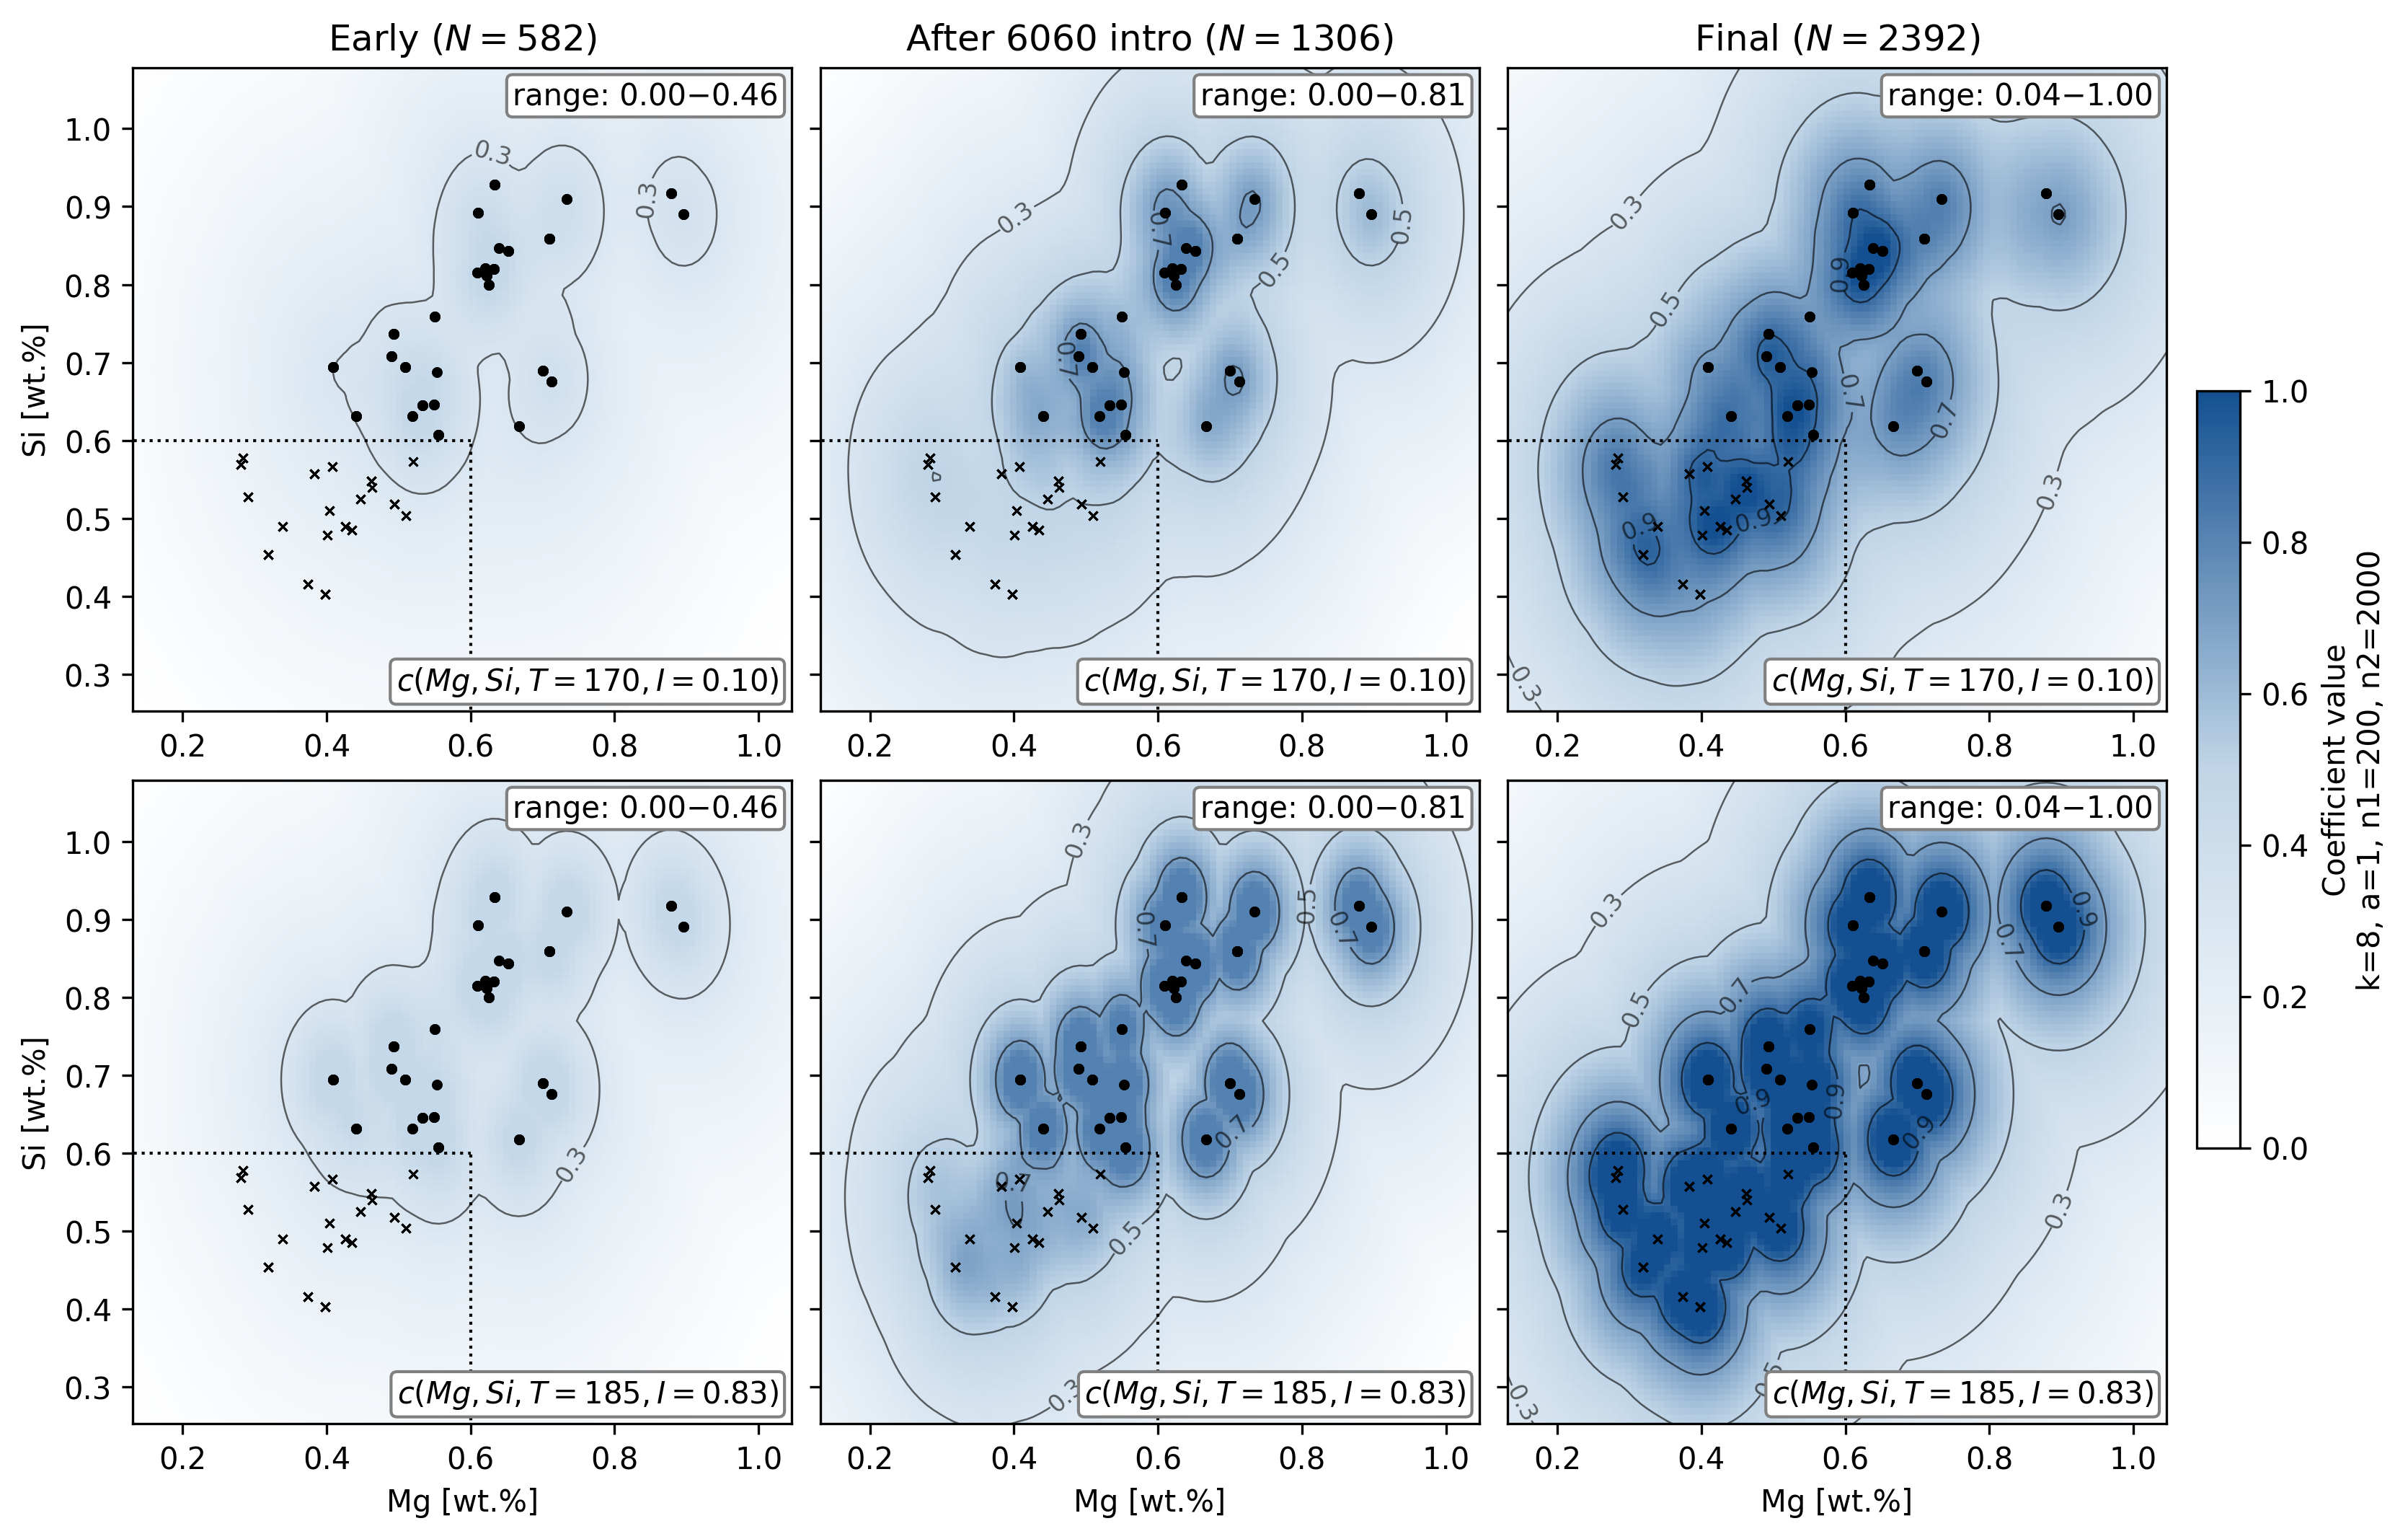

In [6]:
# Figure 3 coefficient field.

temp_6060 = 170
scheil_6060 = 0.10
temp_non6060 = 185
scheil_non6060 = 0.83

widen = 0.15
mg_min, mg_max = df_test["Mg [wt.%]"].min(), df_test["Mg [wt.%]"].max()
si_min, si_max = df_test["Si [wt.%]"].min(), df_test["Si [wt.%]"].max()

mg_grid, si_grid = np.meshgrid(
    np.linspace(mg_min - widen, mg_max + widen, 100),
    np.linspace(si_min - widen, si_max + widen, 100),
)

mg_flat = mg_grid.ravel()
si_flat = si_grid.ravel()


def compute_coeff_grid(df_train_iter, temp_value, scheil_value):
    X_coeff = df_train_iter[COEFF_COLS].to_numpy()

    coeff_model = build_coeff_model(
        X_coeff,
        k=COEFF_PARAMS["k"],
        sample_size=COEFF_PARAMS["sample_size"],
        sharpness=COEFF_PARAMS["sharpness"],
        n1=COEFF_PARAMS["n1"],
        n2=COEFF_PARAMS["n2"],
        verbose=False,
    )

    coeff_grid = np.array(
        [
            coefficient_for_point(coeff_model, [mg, si, temp_value, scheil_value])
            for mg, si in zip(mg_flat, si_flat)
        ],
        dtype=float,
    )

    return coeff_grid.reshape(mg_grid.shape)


idx_early = find_iter_index_for_N(int(breakpoints[0] / 2))
idx_intro = find_iter_index_for_N(int(breakpoints[0] * 1.05))
idx_final = find_iter_index_for_N(breakpoints[1])

df_train_early = df_train_seq.iloc[:train_sizes[idx_early]]
df_train_intro = df_train_seq.iloc[:train_sizes[idx_intro]]
df_train_final = df_train_seq.iloc[:train_sizes[idx_final]]

stage_sets = [df_train_early, df_train_intro, df_train_final]
stage_titles = [
    f"Early ($N={train_sizes[idx_early]}$)",
    f"After 6060 intro ($N={train_sizes[idx_intro]}$)",
    f"Final ($N={train_sizes[idx_final]}$)",
]

fixed_rows = [
    (temp_6060, scheil_6060),
    (temp_non6060, scheil_non6060),
]

grids = [
    [compute_coeff_grid(stage_df, temp_value, scheil_value) for stage_df in stage_sets]
    for temp_value, scheil_value in fixed_rows
]

soft_cmap = mcolors.LinearSegmentedColormap.from_list(
    "softmap",
    ["#ffffff", "#c0d5e7", "#145091"],
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True, constrained_layout=True)

imgs = [[None] * 3 for _ in range(2)]

for row in range(2):
    for col in range(3):
        ax = axes[row, col]

        im = ax.pcolormesh(
            mg_grid,
            si_grid,
            grids[row][col],
            shading="auto",
            cmap=soft_cmap,
            vmin=0,
            vmax=1,
            rasterized=False,
        )
        imgs[row][col] = im

        levels = [0.3, 0.5, 0.7, 0.9]
        if grids[row][col].max() > 0.1:
            cs = ax.contour(
                mg_grid,
                si_grid,
                grids[row][col],
                levels=levels,
                colors="k",
                linewidths=0.6,
                alpha=0.6,
            )
            ax.clabel(
                cs,
                cs.levels,
                inline=True,
                fmt={lvl: f"{lvl:g}" for lvl in levels},
                fontsize=8,
                inline_spacing=3,
                rightside_up=True,
            )

        min_coeff = grids[row][col].min()
        max_coeff = grids[row][col].max()

        ax.annotate(
            f"range: {min_coeff:.2f}−{max_coeff:.2f}",
            xy=(0.98, 0.98),
            xycoords="axes fraction",
            ha="right",
            va="top",
            fontsize=10,
            zorder=100,
            clip_on=False,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=1.0),
        )

        df_non = df_test[~df_test["is_6060"]]
        df_6060 = df_test[df_test["is_6060"]]

        ax.scatter(
            df_non["Mg [wt.%]"],
            df_non["Si [wt.%]"],
            s=8,
            alpha=0.9,
            facecolors="k",
            edgecolors="k",
            linewidths=0.7,
        )

        ax.scatter(
            df_6060["Mg [wt.%]"],
            df_6060["Si [wt.%]"],
            s=8,
            alpha=0.9,
            facecolors="k",
            edgecolors="k",
            marker="x",
            linewidths=0.7,
        )

        temp_value, scheil_value = fixed_rows[row]
        ax.annotate(
            f"$c(Mg, Si, T={temp_value}, I={scheil_value:.2f})$",
            xy=(0.98, 0.02),
            xycoords="axes fraction",
            ha="right",
            va="bottom",
            fontsize=10,
            zorder=100,
            clip_on=False,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=1.0),
        )

        # 6060 boundary: Mg < 0.6 and Si < 0.6.
        ax.plot([0.0, 0.6], [0.6, 0.6], color="k", linestyle=":", linewidth=1)
        ax.plot([0.6, 0.6], [0.0, 0.6], color="k", linestyle=":", linewidth=1)

        ax.set_xlim(mg_min - widen, mg_max + widen)
        ax.set_ylim(si_min - widen, si_max + widen)

        if row == 1:
            ax.set_xlabel("Mg [wt.%]")
        if col == 0:
            ax.set_ylabel("Si [wt.%]")
        if row == 0:
            ax.set_title(stage_titles[col])

cax = fig.add_axes([1.01, 0.25, 0.02, 0.5])
fig.colorbar(
    imgs[1][2],
    cax=cax,
    label=f"Coefficient value\nk={k}, a={sharpness}, n1={n1}, n2={n2}",
)

# fig.set_dpi(600)
fig.set_size_inches(10, 7)
plt.show()

## 7. Incremental experiment summary

Generate the Figure 4 summary:

- sequence-wise `Rp0.2` distribution with split markers
- test-set RMSE evolution for `6060` and `non-6060`
- average adaptive coefficient evolution and dataset-size scaling `g(N)`

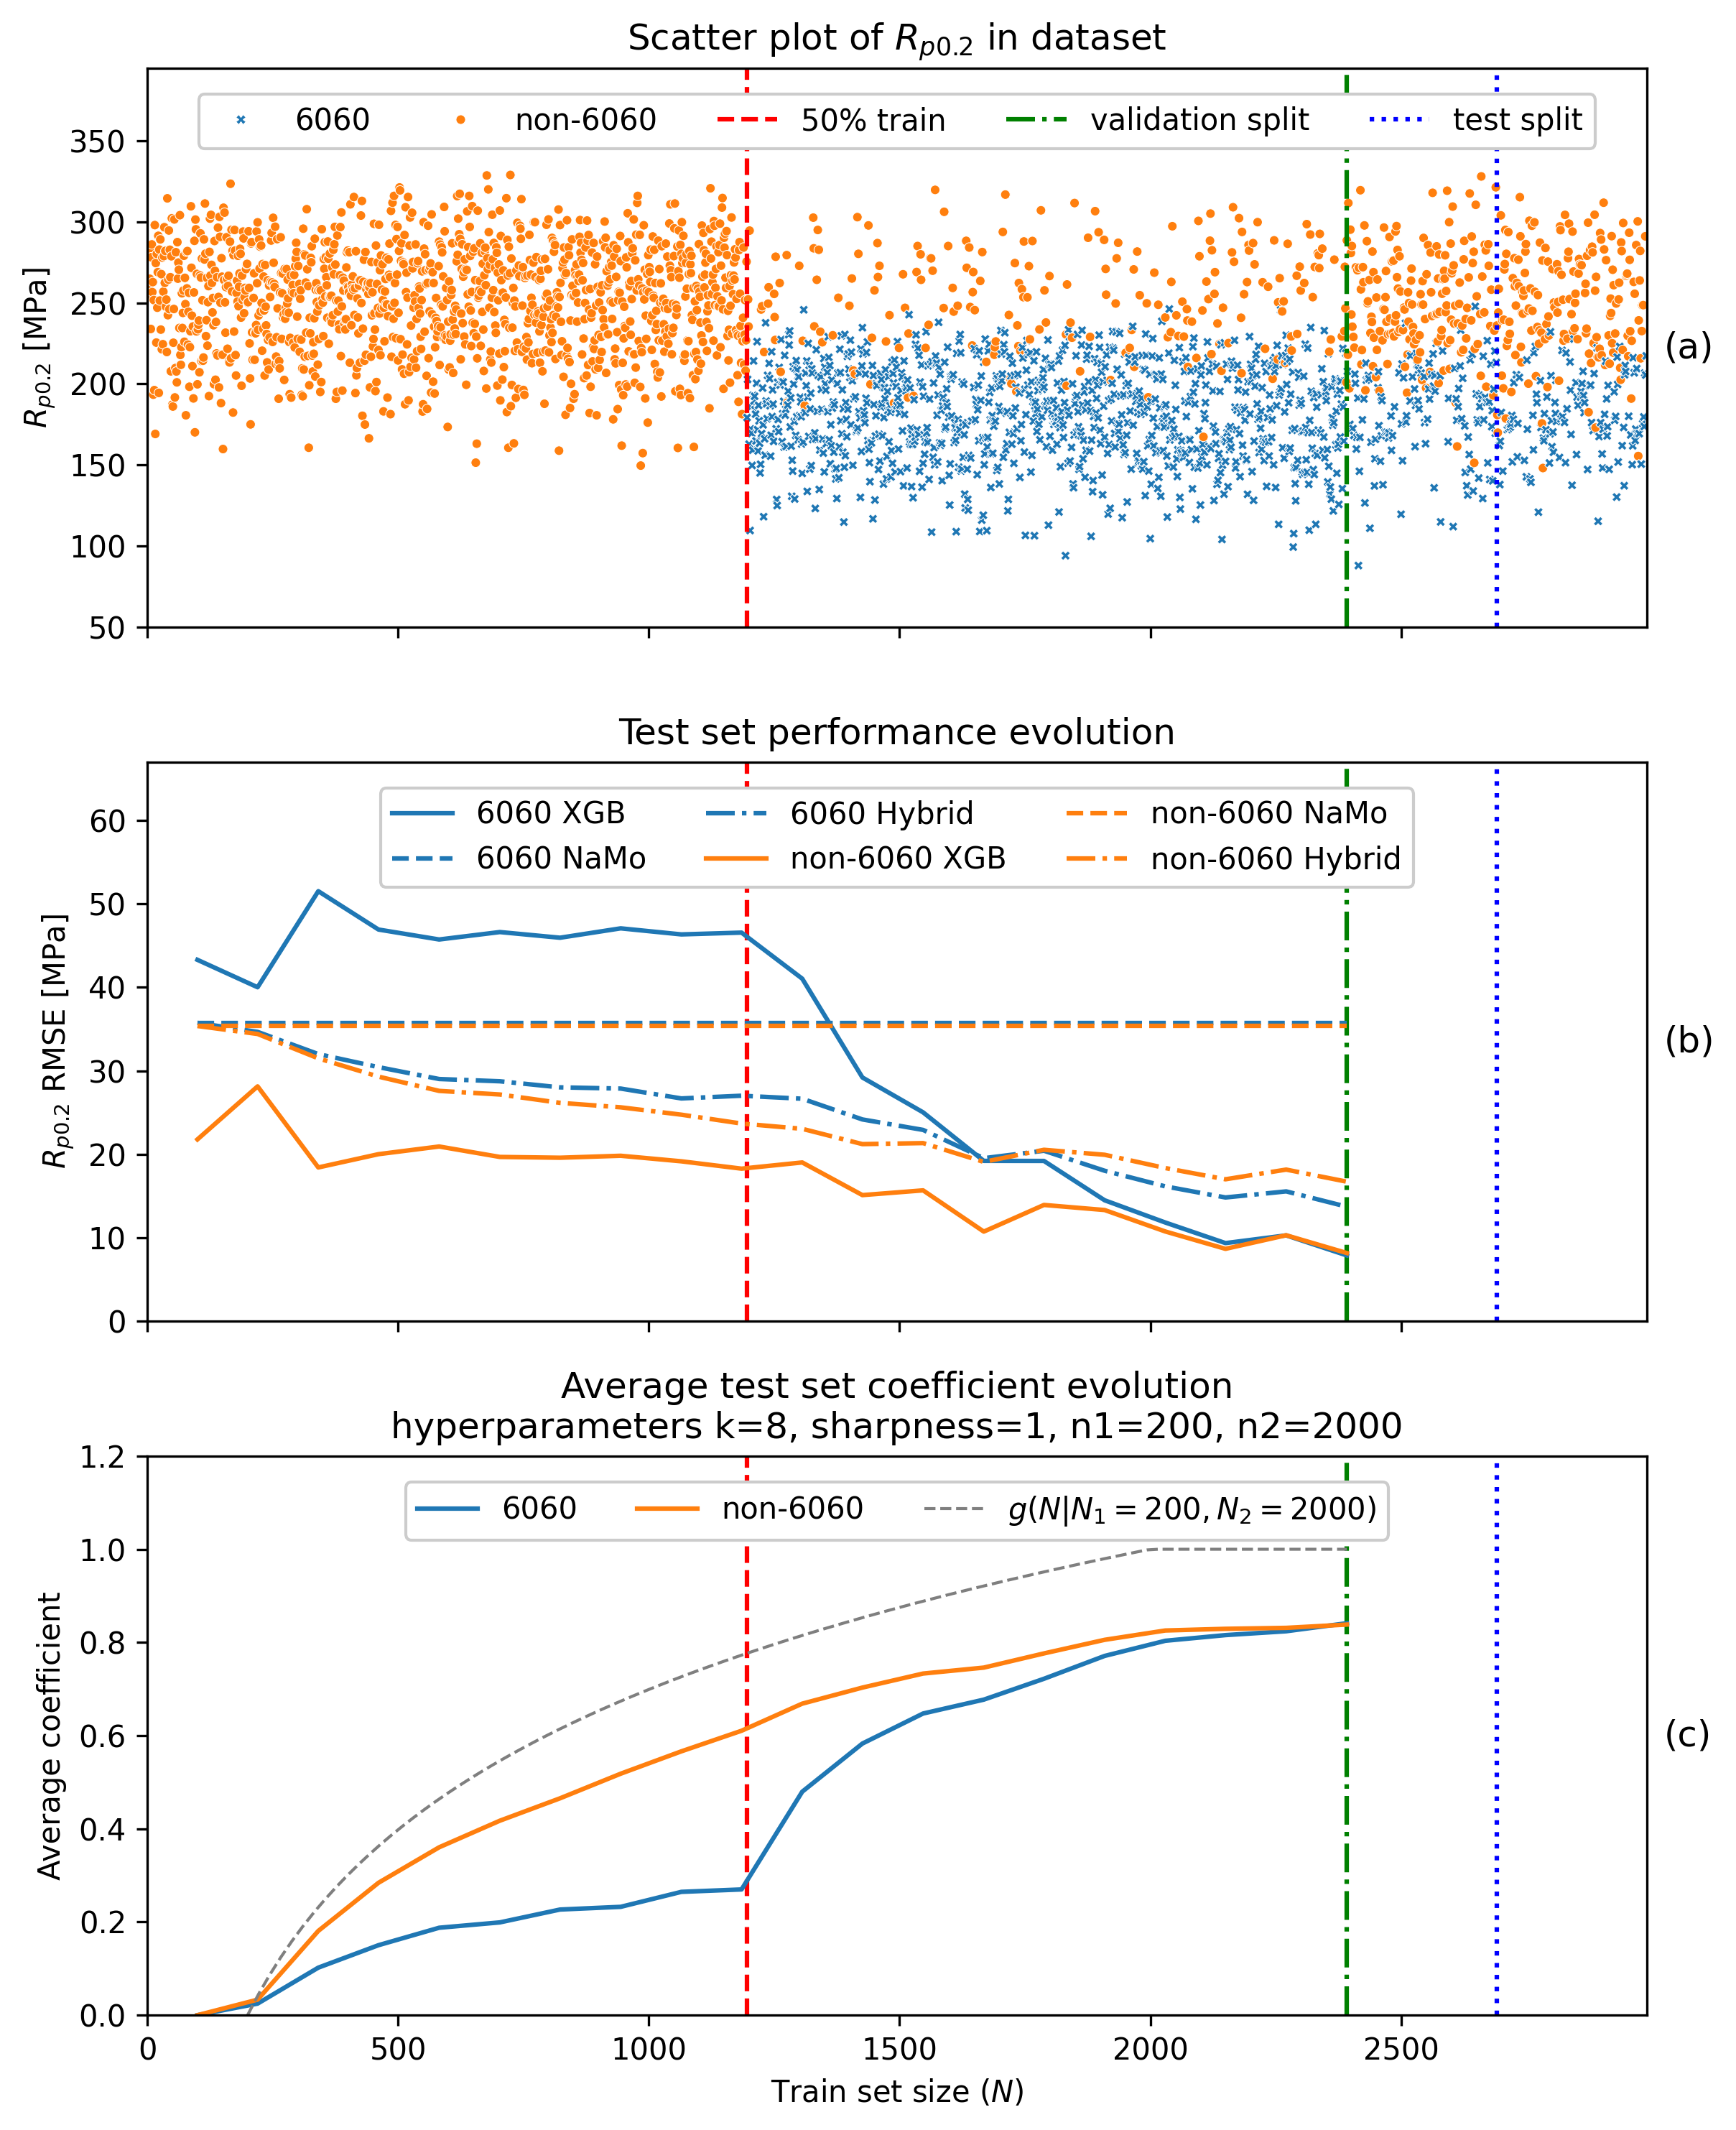

In [7]:
def rmse_6060_vs_non6060(
    all_iter_preds,
    true_col="Rp0.2_test",
    xgb_col="Rp0.2_xgb",
    namo_col="NaMo Rp02",
    hybrid_col="Rp0.2 hybrid",
):
    rmse_dict = {
        "6060 XGB": [],
        "non-6060 XGB": [],
        "6060 NaMo": [],
        "non-6060 NaMo": [],
        "6060 Hybrid": [],
        "non-6060 Hybrid": [],
    }

    for df_pred in all_iter_preds:
        is_6060 = df_pred["is_6060"].astype(bool)

        for label, mask in [("6060", is_6060), ("non-6060", ~is_6060)]:
            y_true = df_pred.loc[mask, true_col].astype(float)
            y_xgb = df_pred.loc[mask, xgb_col].astype(float)
            y_namo = df_pred.loc[mask, namo_col].astype(float)
            y_hybrid = df_pred.loc[mask, hybrid_col].astype(float)

            rmse_dict[f"{label} XGB"].append(safe_rmse(y_true, y_xgb))
            rmse_dict[f"{label} NaMo"].append(safe_rmse(y_true, y_namo))
            rmse_dict[f"{label} Hybrid"].append(safe_rmse(y_true, y_hybrid))

    return rmse_dict


rmse_6060 = rmse_6060_vs_non6060(all_iter_preds_test)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10))

df_full["idx"] = df_full.index
df_full["alloy_type"] = np.where(df_full["is_6060"], "6060", "non-6060")

hue_order = sorted(df_full["alloy_type"].dropna().unique())

sns.scatterplot(
    x="idx",
    y="Rp0.2 [MPa]",
    hue="alloy_type",
    data=df_full,
    s=10,
    style="alloy_type",
    ax=ax1,
    hue_order=hue_order,
)

for ax in (ax1, ax2, ax3):
    ax.axvline(len(df_train_seq) * 0.5, color="red", linestyle="--", label="50% train")
    ax.axvline(len(df_train_seq), color="green", linestyle="-.", label="validation split")
    ax.axvline(
        len(df_train_seq) + len(df_val),
        color="blue",
        linestyle=":",
        label="test split",
    )

ax1.set_ylim(50, df_full["Rp0.2 [MPa]"].max() * 1.2)
ax1.set_xlabel("")
ax1.set_xticklabels([])
ax1.set_ylabel("$R_{p0.2}$ [MPa]")
ax1.set_title("Scatter plot of $R_{p0.2}$ in dataset")
ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=7,
    fontsize=10,
    framealpha=1,
    facecolor="white",
)

colors = {"6060": "tab:blue", "non-6060": "tab:orange"}
linestyles = {"XGB": "-", "NaMo": "--", "Hybrid": "-."}

max_rmse = 0
for label in ["6060", "non-6060"]:
    for model in ["XGB", "NaMo", "Hybrid"]:
        ax2.plot(
            train_sizes,
            rmse_6060[f"{label} {model}"],
            label=f"{label} {model}",
            color=colors[label],
            linestyle=linestyles[model],
        )
        max_rmse = max(max_rmse, np.nanmax(rmse_6060[f"{label} {model}"]))

ax2.set_ylim(0, max_rmse * 1.3)
ax2.set_xticklabels([])
ax2.set_ylabel("$R_{p0.2}$ RMSE [MPa]")
ax2.set_title("Test set performance evolution")

handles, labels = ax2.get_legend_handles_labels()
for i in [0, 0, 0]:
    handles.pop(i)
    labels.pop(i)

ax2.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=10,
    handles=handles,
    labels=labels,
    framealpha=1,
    facecolor="white",
)

avg_coeff_6060 = []
avg_coeff_non6060 = []

for df_pred in all_iter_preds_test:
    is_6060 = df_pred["is_6060"].astype(bool)
    avg_coeff_6060.append(df_pred.loc[is_6060, "coeff"].mean())
    avg_coeff_non6060.append(df_pred.loc[~is_6060, "coeff"].mean())

ax3.set_ylim(0, 1.2)
ax3.plot(train_sizes, avg_coeff_6060, label="6060", color="tab:blue")
ax3.plot(train_sizes, avg_coeff_non6060, label="non-6060", color="tab:orange")

xs = np.linspace(n1, train_sizes[-1], 100)
size_scale = [g_of_n(N, n1, n2) for N in xs]

ax3.plot(
    xs,
    size_scale,
    label=f"$g(N|N_1={n1}, N_2={n2})$",
    linestyle="--",
    linewidth=1,
    color="tab:gray",
)

ax3.set_xlabel("Train set size ($N$)")
ax3.set_ylabel("Average coefficient")
ax3.set_title(
    "Average test set coefficient evolution\n"
    f"hyperparameters k={k}, sharpness={sharpness}, n1={n1}, n2={n2}"
)

handles, labels = ax3.get_legend_handles_labels()
for i in [0, 0, 0]:
    handles.pop(i)
    labels.pop(i)

ax3.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=5,
    fontsize=10,
    handles=handles,
    labels=labels,
    framealpha=1,
    facecolor="white",
)

[ax.set_xlim(0, len(df_full)) for ax in (ax1, ax2, ax3)]

plt.subplots_adjust(top=0.85)
plt.tight_layout()

offset = 0.01
for ax, label in zip([ax1, ax2, ax3], ["(a)", "(b)", "(c)"]):
    bbox = ax.get_position()
    x = bbox.x1 + offset
    y = 0.5 * (bbox.y0 + bbox.y1)
    fig.text(
        x,
        y,
        label,
        ha="left",
        va="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )

# fig.set_dpi(300)
plt.show()

## 8. Representative RMSE summaries

Compute Table 3 RMSE summaries for `Rp0.2` and `Rm` at three representative training sizes: early, after `6060` introduction, and final.

The values are expected to differ from the paper because DS2 and the NaMo estimates are synthetic replacements.

In [8]:
target_N = [
    int(breakpoints[0] / 2),
    int(breakpoints[0] * 1.05),
    int(breakpoints[1]),
]

actual_N = []
actual_idx = []

print("Train sizes available, closest matches:")
for N in target_N:
    idx = find_iter_index_for_N(N)
    actual_idx.append(idx)
    actual_N.append(int(train_sizes[idx]))
    print(f" requested N={N} -> iteration index {idx}, actual train_size = {actual_N[-1]}")


def build_rmse_table(target_name):
    if target_name == "Rp0.2":
        true_col = "Rp0.2_test"
        namo_col = "NaMo Rp02"
        xgb_col = "Rp0.2_xgb"
        hybrid_col = "Rp0.2 hybrid"
    elif target_name == "Rm":
        true_col = "Rm_test"
        namo_col = "NaMo Rm"
        xgb_col = "Rm_xgb"
        hybrid_col = "Rm hybrid"
    else:
        raise ValueError("target_name must be 'Rp0.2' or 'Rm'.")

    cols = pd.MultiIndex.from_product(
        [["6060", "non-6060"], actual_N],
        names=("alloy_type", "N"),
    )

    table = pd.DataFrame(index=["NaMo", "XGBoost", "Hybrid"], columns=cols, dtype=float)

    for N in actual_N:
        idx = find_iter_index_for_N(N)
        df_pred = all_iter_preds_test[idx]

        is_6060 = df_pred["is_6060"].astype(bool)
        is_non = ~is_6060

        table.loc["NaMo", ("6060", N)] = safe_rmse(
            df_pred.loc[is_6060, true_col],
            df_pred.loc[is_6060, namo_col],
        )
        table.loc["NaMo", ("non-6060", N)] = safe_rmse(
            df_pred.loc[is_non, true_col],
            df_pred.loc[is_non, namo_col],
        )

        table.loc["XGBoost", ("6060", N)] = safe_rmse(
            df_pred.loc[is_6060, true_col],
            df_pred.loc[is_6060, xgb_col],
        )
        table.loc["XGBoost", ("non-6060", N)] = safe_rmse(
            df_pred.loc[is_non, true_col],
            df_pred.loc[is_non, xgb_col],
        )

        table.loc["Hybrid", ("6060", N)] = safe_rmse(
            df_pred.loc[is_6060, true_col],
            df_pred.loc[is_6060, hybrid_col],
        )
        table.loc["Hybrid", ("non-6060", N)] = safe_rmse(
            df_pred.loc[is_non, true_col],
            df_pred.loc[is_non, hybrid_col],
        )

    return table


rp_table = build_rmse_table("Rp0.2")
rm_table = build_rmse_table("Rm")

print("Rp0.2 RMSE [MPa]")
display(rp_table.round(1))

print("Rm RMSE [MPa]")
display(rm_table.round(1))

print("Coefficient parameters:", COEFF_PARAMS)

Train sizes available, closest matches:
 requested N=598 -> iteration index 4, actual train_size = 582
 requested N=1255 -> iteration index 10, actual train_size = 1306
 requested N=2392 -> iteration index 19, actual train_size = 2392
Rp0.2 RMSE [MPa]


alloy_type   6060               non-6060              
N            582    1306   2392     582    1306   2392
NaMo       35.700 35.700 35.700   35.400 35.400 35.400
XGBoost    45.700 41.000  7.900   20.900 19.000  8.200
Hybrid     29.000 26.700 13.700   27.600 23.100 16.700

Rm RMSE [MPa]


alloy_type   6060               non-6060              
N            582    1306   2392     582    1306   2392
NaMo       24.400 24.400 24.400   24.400 24.400 24.400
XGBoost    46.600 43.700  9.700   20.800 19.700 10.300
Hybrid     19.800 23.300 11.400   18.800 18.400 13.400

Coefficient parameters: {'k': 8, 'sharpness': 1, 'n1': 200, 'n2': 2000, 'sample_size': 10000}


## 9. Robustness variants

Prepare the two Figure 5 comparison variants:

- variant (a): static validation-optimized coefficient `c`
- variant (b): adaptive coefficient without dataset-size scaling, equivalent to `g = 1`

These variants isolate the effect of distance adaptivity and training-size scaling.

In [9]:
def overall_rp02_rmse_curves(all_iter_preds):
    rmse_xgb = []
    rmse_namo = []
    rmse_hybrid = []

    for df_pred in all_iter_preds:
        y_true = df_pred["Rp0.2_test"].astype(float).to_numpy()

        rmse_xgb.append(safe_rmse(y_true, df_pred["Rp0.2_xgb"].astype(float).to_numpy()))
        rmse_namo.append(safe_rmse(y_true, df_pred["NaMo Rp02"].astype(float).to_numpy()))
        rmse_hybrid.append(safe_rmse(y_true, df_pred["Rp0.2 hybrid"].astype(float).to_numpy()))

    return rmse_xgb, rmse_namo, rmse_hybrid


# Baseline adaptive hybrid on test set.
rmse_xgb, rmse_namo, rmse_hybrid = overall_rp02_rmse_curves(all_iter_preds_test)

# Variant (a): validation-optimized static c.
coeffs = list(np.arange(0, 1.01, 0.01))
coeff_val_rmses = []

for coeff in tqdm(coeffs, desc="Static-c grid on validation set"):
    all_iter_preds_val_static_c, _ = recompute_hybrid_predictions(
        base_iter_preds_val,
        df_val,
        fixed_coeff=coeff,
    )

    rmses = []
    for df_pred in all_iter_preds_val_static_c:
        y_true = df_pred["Rp0.2_test"].astype(float).to_numpy()
        y_hybrid = df_pred["Rp0.2 hybrid"].astype(float).to_numpy()
        rmses.append(safe_rmse(y_true, y_hybrid))

    coeff_val_rmses.append(float(np.nanmean(rmses)))

best_idx = int(np.nanargmin(coeff_val_rmses))
best_coeff = float(coeffs[best_idx])
best_rmse = float(coeff_val_rmses[best_idx])

print(f"Best static coefficient from validation set: c={best_coeff:.2f}, RMSE={best_rmse:.3f} MPa")

# Apply validation-optimized static c on test set.
all_iter_preds_test_static_c, _ = recompute_hybrid_predictions(
    base_iter_preds_test,
    df_test,
    fixed_coeff=best_coeff,
)

_, _, rmse_hybrid_static = overall_rp02_rmse_curves(all_iter_preds_test_static_c)

# Variant (b): no dataset-size scaling, i.e. g=1.
all_iter_preds_test_no_size, _ = recompute_hybrid_predictions(
    base_iter_preds_test,
    df_test,
    coeff_func=coefficient_for_point_no_size_scale,
)

_, _, rmse_hybrid_no_size = overall_rp02_rmse_curves(all_iter_preds_test_no_size)

Static-c grid on validation set:   0%|          | 0/101 [00:00<?, ?it/s]

Best static coefficient from validation set: c=0.59, RMSE=16.714 MPa


## 10. Robustness comparison

Generate the Figure 5 comparison of overall `Rp0.2` RMSE trajectories for DDM, PBM, the adaptive hybrid, and the two hybrid variants.

The comparison assesses how the adaptive coefficient and dataset-size scaling contribute to the hybrid model behavior.

Best static validation coefficient c: 0.59
Average Rp0.2 RMSE for hybrid original: 24.31 MPa
Average Rp0.2 RMSE for hybrid var. (a): 17.55 MPa
Average Rp0.2 RMSE for hybrid var. (b): 22.60 MPa


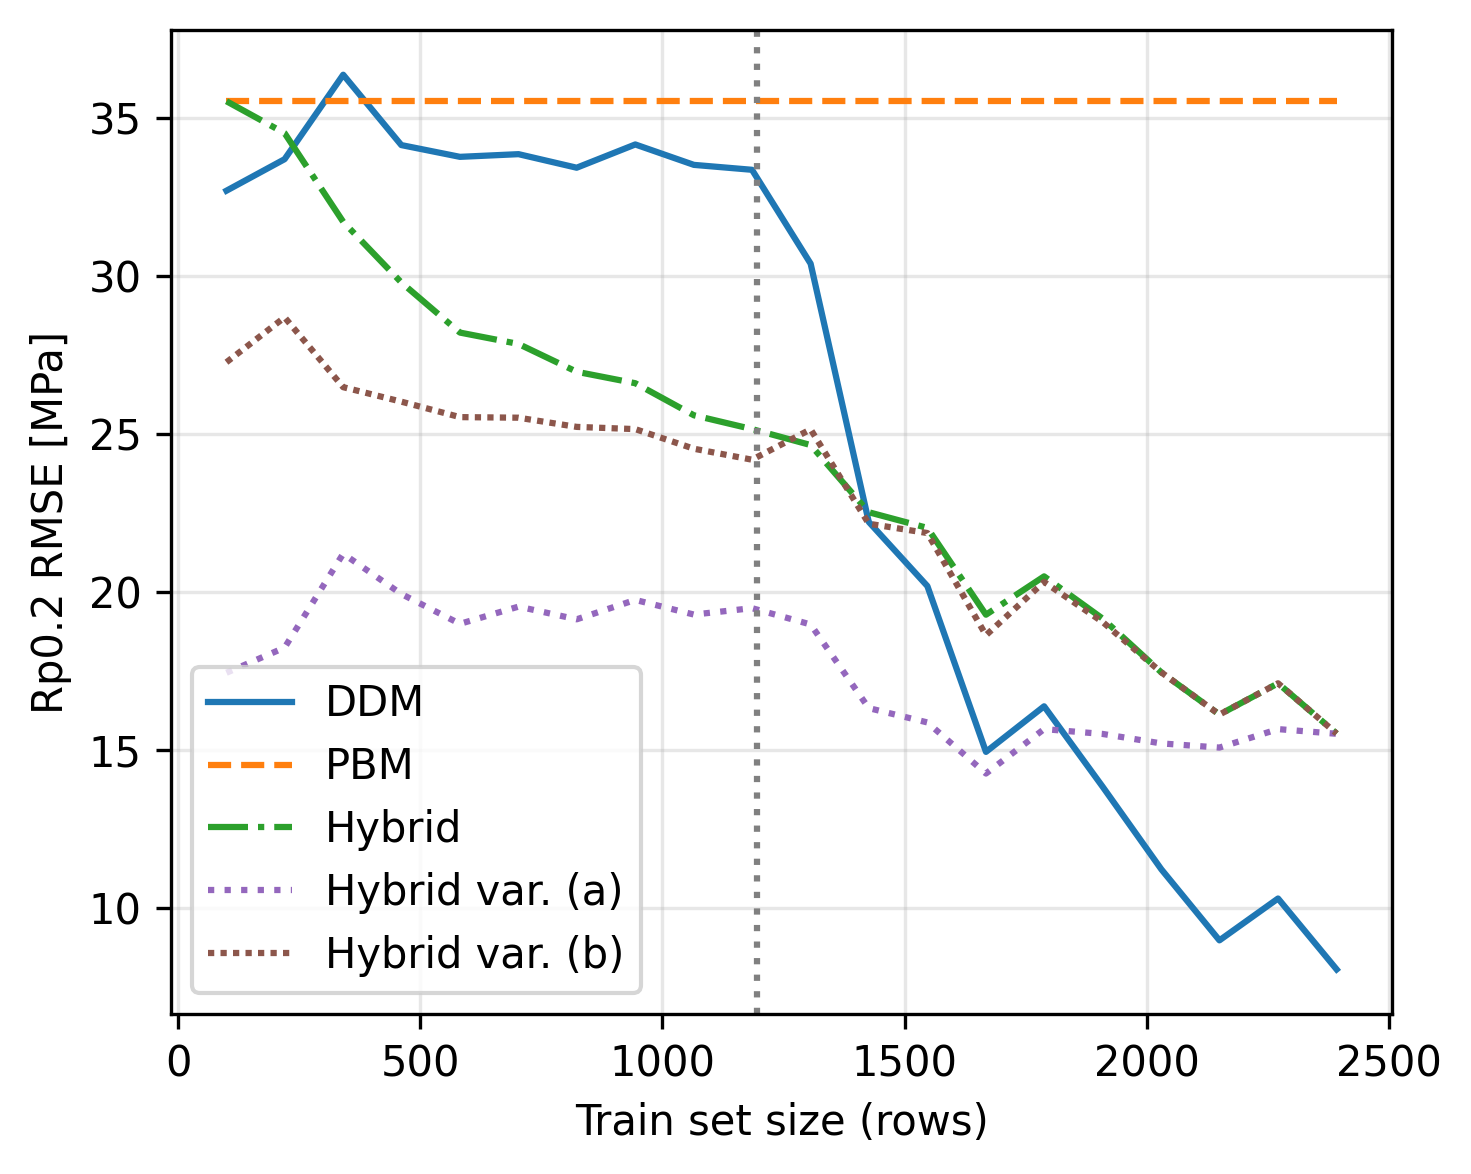

In [10]:
plt.figure(figsize=(5, 4))

plt.plot(
    train_sizes,
    rmse_xgb,
    label="DDM",
    linewidth=1.5,
    linestyle="-",
    color="tab:blue",
)

plt.plot(
    train_sizes,
    rmse_namo,
    label="PBM",
    linewidth=1.5,
    linestyle="--",
    color="tab:orange",
)

plt.plot(
    train_sizes,
    rmse_hybrid,
    label="Hybrid",
    linewidth=1.5,
    linestyle="-.",
    color="tab:green",
)

plt.plot(
    train_sizes,
    rmse_hybrid_static,
    label="Hybrid var. (a)",
    linewidth=1.5,
    linestyle=":",
    color="tab:purple",
)

plt.plot(
    train_sizes,
    rmse_hybrid_no_size,
    label="Hybrid var. (b)",
    linewidth=1.5,
    linestyle=(0, (1, 1)),
    color="tab:brown",
)

plt.gca().axvline(
    len(df_train_seq) * 0.5,
    color="gray",
    linewidth=1.5,
    linestyle=":",
)

print(f"Best static validation coefficient c: {best_coeff:.2f}")
print(f"Average Rp0.2 RMSE for hybrid original: {np.nanmean(rmse_hybrid):0.2f} MPa")
print(f"Average Rp0.2 RMSE for hybrid var. (a): {np.nanmean(rmse_hybrid_static):0.2f} MPa")
print(f"Average Rp0.2 RMSE for hybrid var. (b): {np.nanmean(rmse_hybrid_no_size):0.2f} MPa")

plt.xlabel("Train set size (rows)")
plt.ylabel("Rp0.2 RMSE [MPa]")
plt.grid(alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()
# plt.gcf().set_dpi(600)
plt.show()

#### Optional export

Uncomment to save table outputs:

In [11]:
# rp_table.to_excel(OUTPUT_DIR / "paper_iii_table3_rp02_synthetic_namo.xlsx")
# rm_table.to_excel(OUTPUT_DIR / "paper_iii_table3_rm_synthetic_namo.xlsx")